# Cardiovascular Disease Classification
Dataset: kaggle.com/datasets/sulianova/cardiovascular-disease-dataset

In [1]:
# --- Setup ---
import importlib, subprocess, sys
def ensure(pkg):
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)
ensure("xgboost")
ensure("shap")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, precision_recall_curve)

import warnings; warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
print("Setup done.")

Setup done.


## Upload data

In [2]:
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(filename, sep=";")
if df_raw.shape[1] == 1:
    df_raw = pd.read_csv(filename, sep=",")

print(filename, "->", df_raw.shape)
df_raw.head()

Saving cardio_train.csv to cardio_train.csv
cardio_train.csv -> (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## Inspect

In [3]:
print(df_raw.dtypes)
print("\nMissing:\n", df_raw.isnull().sum())
print("\nDuplicated rows:", df_raw.duplicated().sum())

TARGET = "cardio" if "cardio" in df_raw.columns else df_raw.columns[-1]
print(f"\nTarget: {TARGET}")
print(df_raw[TARGET].value_counts())
print(df_raw[TARGET].value_counts(normalize=True).round(3))

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

Missing:
 id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Duplicated rows: 0

Target: cardio
cardio
0    35021
1    34979
Name: count, dtype: int64
cardio
0    0.5
1    0.5
Name: proportion, dtype: float64


## Clean

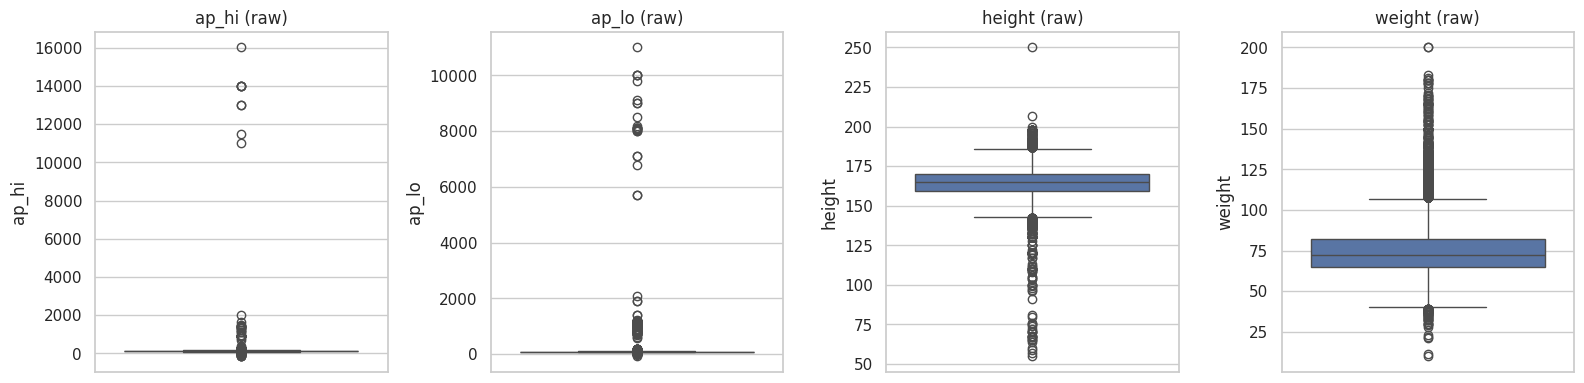

Rows before: 70000  after: 68614  removed: 1386 (2.0%)
cardio
0    0.505
1    0.495
Name: proportion, dtype: float64


In [4]:
df = df_raw.copy()

for idcol in ["id", "ID", "Id"]:
    if idcol in df.columns:
        df = df.drop(columns=[idcol])

if "age" in df.columns and df["age"].max() > 200:
    df["age"] = (df["age"] / 365.25).round(1)

# --- visualize raw values before filtering, so the cleaning decision is justified, not assumed ---
raw_check_cols = [c for c in ["ap_hi", "ap_lo", "height", "weight"] if c in df.columns]
fig, axes = plt.subplots(1, len(raw_check_cols), figsize=(4*len(raw_check_cols), 4))
for ax, col in zip(axes, raw_check_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f"{col} (raw)")
plt.tight_layout(); plt.show()

before = len(df)
mask = pd.Series(True, index=df.index)
bounds = {"ap_hi": (70, 240), "ap_lo": (40, 180), "height": (120, 210), "weight": (30, 200)}
for col, (lo, hi) in bounds.items():
    if col in df.columns:
        mask &= df[col].between(lo, hi)
if "ap_hi" in df.columns and "ap_lo" in df.columns:
    mask &= df["ap_lo"] < df["ap_hi"]

df = df[mask].reset_index(drop=True)
print(f"Rows before: {before}  after: {len(df)}  removed: {before-len(df)} ({(before-len(df))/before:.1%})")
print(df[TARGET].value_counts(normalize=True).round(3))

## Feature engineering

In [5]:
# BMI and pulse pressure are standard, clinically meaningful derived features for this dataset -
# raw height/weight and raw ap_hi/ap_lo are less directly informative on their own.
if "height" in df.columns and "weight" in df.columns:
    df["bmi"] = (df["weight"] / (df["height"]/100)**2).round(2)

if "ap_hi" in df.columns and "ap_lo" in df.columns:
    df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]

print(df[["bmi", "pulse_pressure"]].describe().round(2) if "bmi" in df.columns else "engineered features added")

            bmi  pulse_pressure
count  68614.00        68614.00
mean      27.46           45.37
std        5.26           11.66
min       10.73            5.00
25%       23.88           40.00
50%       26.35           40.00
75%       30.12           50.00
max      108.17          140.00


## Duplicate / leakage check

In [6]:
dup_full = df.duplicated().sum()
dup_no_target = df.drop(columns=[TARGET]).duplicated().sum()
print(f"Fully duplicated rows: {dup_full} ({dup_full/len(df):.1%})")
print(f"Duplicated on features only (label may differ): {dup_no_target} ({dup_no_target/len(df):.1%})")
print("-> if either is high (>10%), trust the de-duplicated sensitivity check near the bottom over the headline metric.")

Fully duplicated rows: 674 (1.0%)
Duplicated on features only (label may differ): 1048 (1.5%)
-> if either is high (>10%), trust the de-duplicated sensitivity check near the bottom over the headline metric.


## EDA

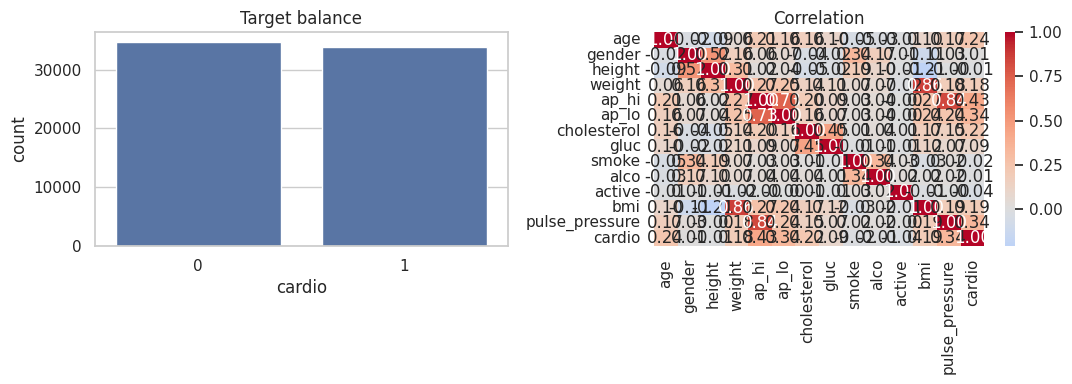

In [7]:
num_cols = [c for c in df.columns if c != TARGET]

# target balance + correlation
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x=TARGET, ax=axes[0]); axes[0].set_title("Target balance")
sns.heatmap(df[num_cols + [TARGET]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Correlation")
plt.tight_layout(); plt.show()

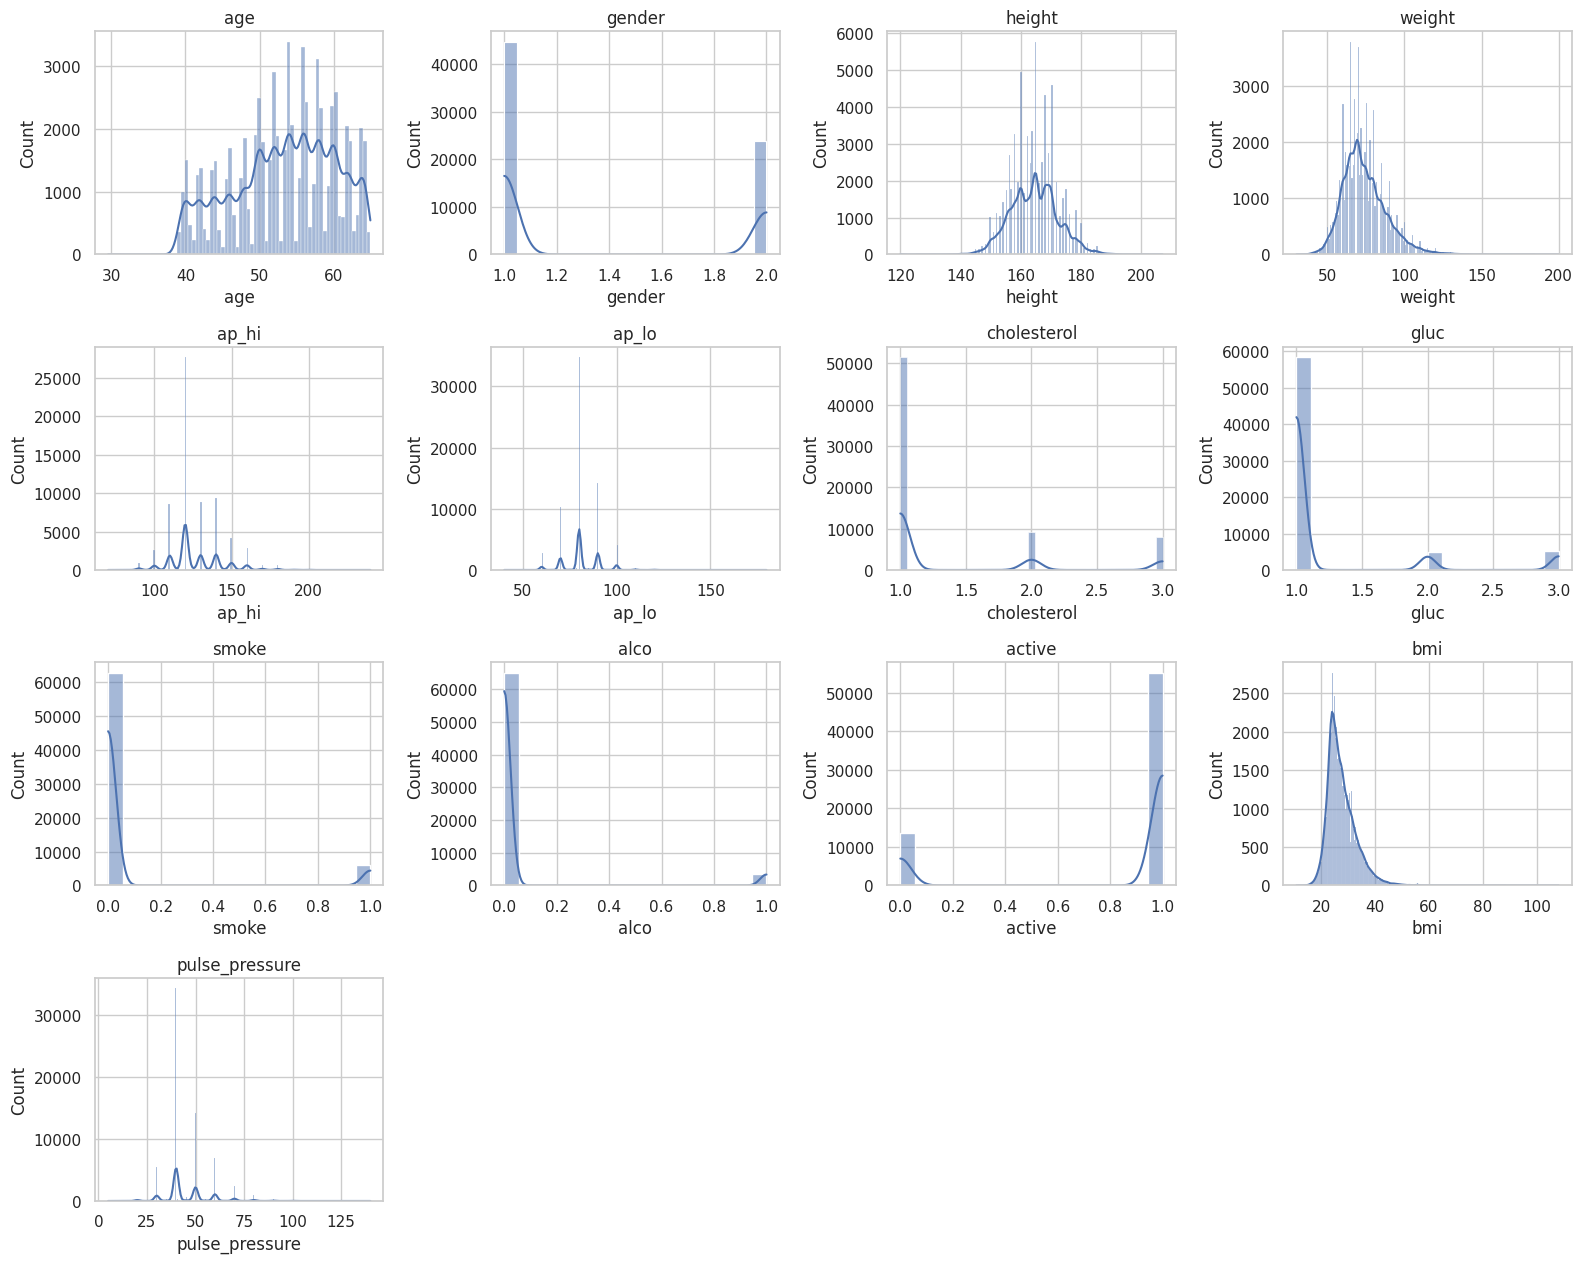

In [8]:
# distribution of each feature
ncols_grid = 4
nrows_grid = int(np.ceil(len(num_cols) / ncols_grid))
fig, axes = plt.subplots(nrows_grid, ncols_grid, figsize=(16, 3.2*nrows_grid))
axes = np.array(axes).flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout(); plt.show()

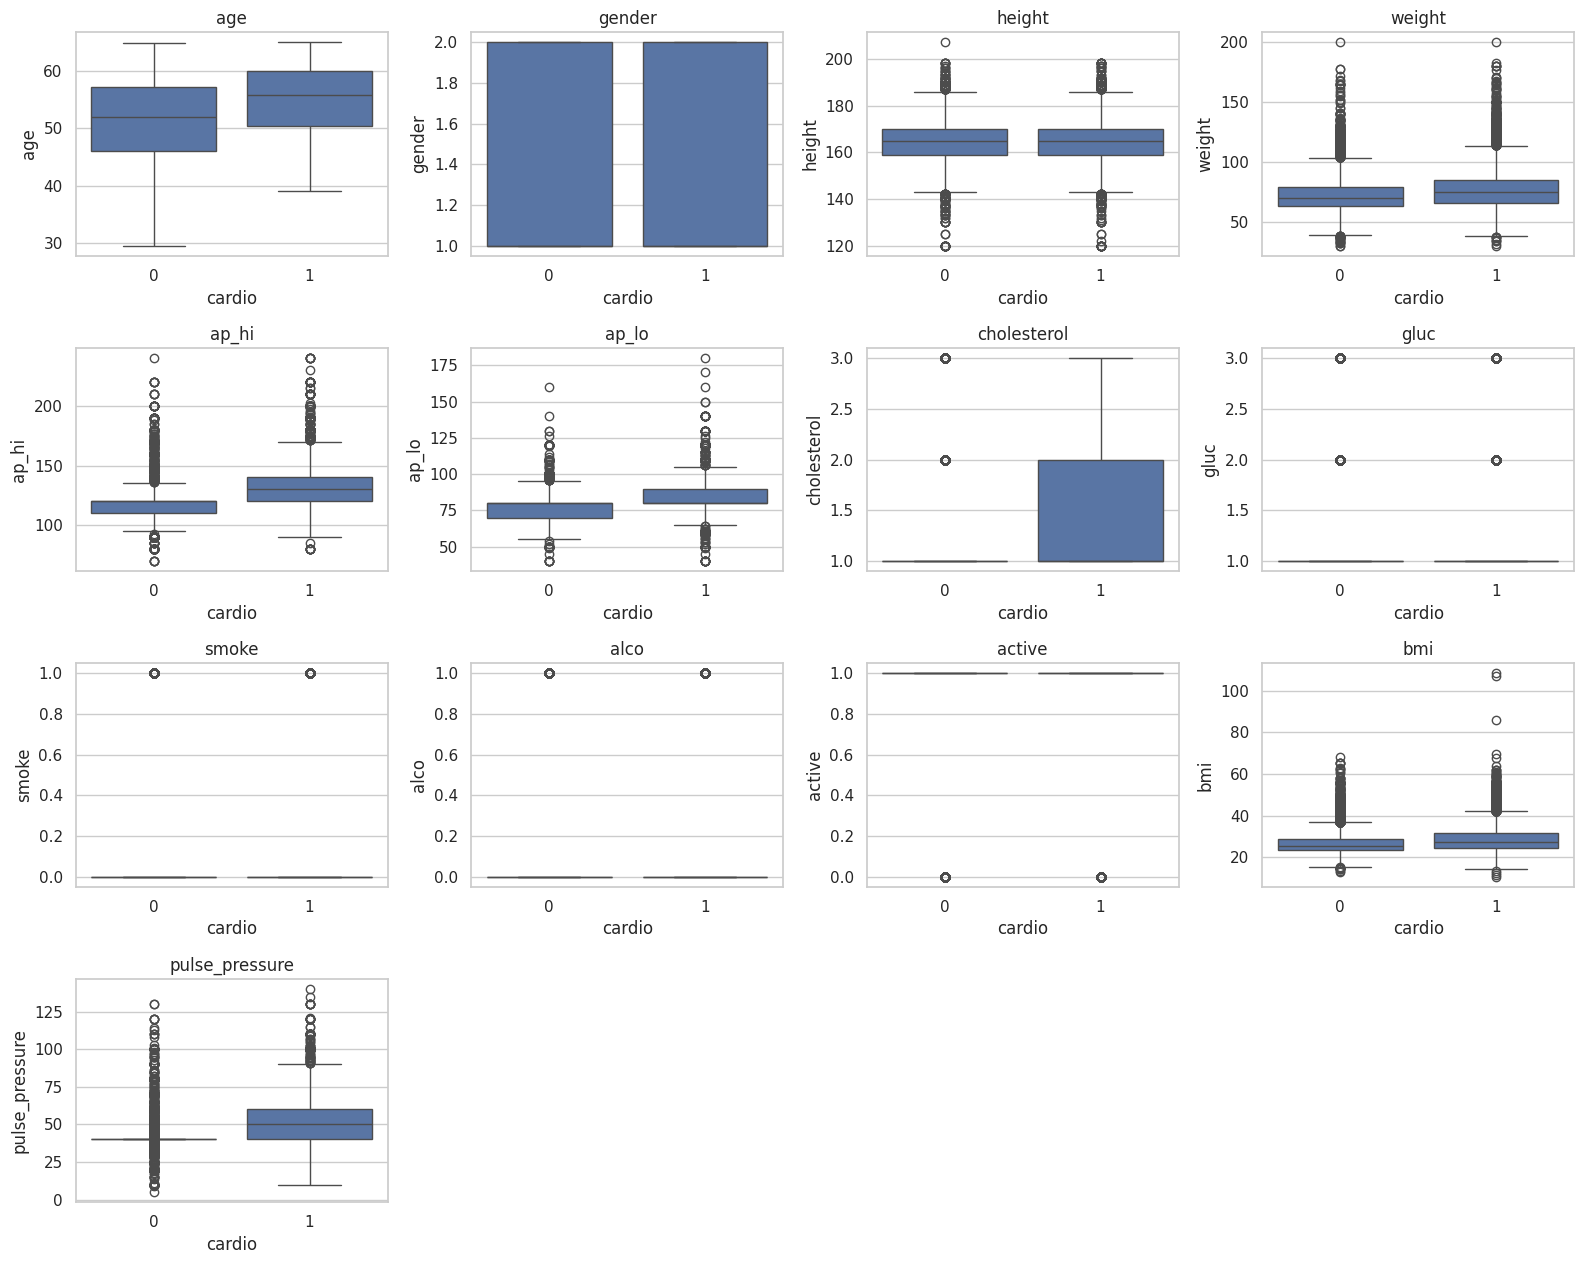

In [9]:
# each feature split by target - the key "does this separate the classes" view
fig, axes = plt.subplots(nrows_grid, ncols_grid, figsize=(16, 3.2*nrows_grid))
axes = np.array(axes).flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=TARGET, y=col, ax=axes[i])
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout(); plt.show()

## Statistical validation

In [10]:
# Mann-Whitney U for continuous/ordinal features between the two target groups, with effect size
group0 = df[df[TARGET]==0]
group1 = df[df[TARGET]==1]

rows = []
for col in num_cols:
    u, p = stats.mannwhitneyu(group0[col], group1[col], alternative="two-sided")
    n1, n2 = len(group0), len(group1)
    rank_biserial = 1 - (2*u)/(n1*n2)   # effect size for Mann-Whitney
    rows.append({"Feature": col, "U": u, "p-value": p, "Effect size (rank-biserial)": round(rank_biserial, 4)})

stat_results = pd.DataFrame(rows).sort_values("Effect size (rank-biserial)", key=abs, ascending=False)
stat_results["Significant (a=0.05)"] = stat_results["p-value"] < 0.05
display(stat_results.round(4))
print("Effect size guide: ~0.1 small, ~0.3 moderate, ~0.5 large. p-value alone is not enough at this sample size.")

,Feature,U,p-value,Effect size (rank-biserial),Significant (a=0.05)
4,ap_hi,292706683.5,0.0000,0.5026,True
12,pulse_pressure,362285995.0,0.0000,0.3843,True
5,ap_lo,363888102.0,0.0000,0.3816,True
0,age,428116927.0,0.0000,0.2724,True
11,bmi,454371250.5,0.0000,0.2278,True
3,weight,465743362.0,0.0000,0.2085,True
6,cholesterol,477680342.5,0.0000,0.1882,True
7,gluc,549700360.0,0.0000,0.0658,True
10,active,606032095.0,0.0000,-0.0299,True
2,height,596799502.5,0.0012,-0.0142,True


Effect size guide: ~0.1 small, ~0.3 moderate, ~0.5 large. p-value alone is not enough at this sample size.


## Split & preprocessing

In [11]:
X = df[num_cols].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

preprocessor = ColumnTransformer([("num", StandardScaler(), num_cols)], remainder="drop")

def make_pipeline(model):
    return Pipeline([("prep", preprocessor), ("model", model)])

print(f"Train: {X_train.shape}   Test: {X_test.shape}")

Train: (54891, 13)   Test: (13723, 13)


## Baselines

In [12]:
dummy = make_pipeline(DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE))
dummy.fit(X_train, y_train)
print("Dummy      -> Acc:", accuracy_score(y_test, dummy.predict(X_test)),
      " F1:", f1_score(y_test, dummy.predict(X_test)))

logreg = make_pipeline(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
logreg.fit(X_train, y_train)
print("LogReg     -> Acc:", accuracy_score(y_test, logreg.predict(X_test)),
      " F1:", f1_score(y_test, logreg.predict(X_test)))

Dummy      -> Acc: 0.5052831013626758  F1: 0.0
LogReg     -> Acc: 0.7228011367776725  F1: 0.7031835205992509


## Model comparison (5-fold CV on training data only)

In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree":       DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=10),
    "Random Forest":       RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "KNN":                 KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
    "XGBoost":             XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                                         eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, mdl in models.items():
    pipe = make_pipeline(mdl)
    oof = cross_val_predict(pipe, X_train, y_train, cv=cv, n_jobs=-1)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    try:
        oof_p = cross_val_predict(pipe, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
        auc = roc_auc_score(y_train, oof_p)
    except Exception:
        auc = np.nan
    rows.append({
        "Model": name, "Accuracy": accuracy_score(y_train, oof),
        "Precision": precision_score(y_train, oof), "Recall": recall_score(y_train, oof),
        "F1": f1_score(y_train, oof), "ROC-AUC": auc,
        "CV F1 mean": scores.mean(), "CV F1 std": scores.std(),
    })
    print(f"{name:<22} CV F1 = {scores.mean():.4f} (+/- {scores.std():.4f})")

cv_results = pd.DataFrame(rows).sort_values("CV F1 mean", ascending=False).reset_index(drop=True)
display(cv_results.round(4))

Logistic Regression    CV F1 = 0.7095 (+/- 0.0034)
Decision Tree          CV F1 = 0.7079 (+/- 0.0056)
Random Forest          CV F1 = 0.7058 (+/- 0.0042)
KNN                    CV F1 = 0.7077 (+/- 0.0024)
XGBoost                CV F1 = 0.7169 (+/- 0.0050)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,CV F1 mean,CV F1 std
0,XGBoost,0.7322,0.7515,0.6854,0.7169,0.7983,0.7169,0.0050
1,Logistic Regression,0.7288,0.7545,0.6695,0.7095,0.7916,0.7095,0.0034
2,Decision Tree,0.7232,0.7406,0.6780,0.7079,0.7788,0.7079,0.0056
3,KNN,0.7201,0.7321,0.6848,0.7077,0.7788,0.7077,0.0024
4,Random Forest,0.7123,0.7142,0.6976,0.7058,0.7728,0.7058,0.0042


## Tune top 2

In [14]:
param_grids = {
    "Random Forest": {
        "model__n_estimators": [200, 300, 500], "model__max_depth": [6, 10, 14, None],
        "model__min_samples_split": [2, 5, 10], "model__min_samples_leaf": [1, 2, 4],
    },
    "XGBoost": {
        "model__n_estimators": [200, 300, 500], "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__subsample": [0.8, 1.0], "model__colsample_bytree": [0.8, 1.0],
    },
    "Decision Tree": {
        "model__max_depth": [4, 6, 8, 10, 14], "model__min_samples_split": [2, 5, 10, 20],
        "model__min_samples_leaf": [1, 2, 5, 10],
    },
    "Logistic Regression": {"model__C": [0.01, 0.1, 1, 10, 100]},
    "KNN": {"model__n_neighbors": [11, 15, 21, 31], "model__weights": ["uniform", "distance"]},
}

top_two = cv_results.head(2)["Model"].tolist()
print("Tuning:", top_two)

tuned = {}
for name in top_two:
    search = RandomizedSearchCV(make_pipeline(models[name]), param_grids[name],
                                n_iter=20, cv=cv, scoring="f1", random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X_train, y_train)
    tuned[name] = search
    base = cv_results.loc[cv_results["Model"] == name, "CV F1 mean"].values[0]
    print(f"{name}: {base:.4f} -> {search.best_score_:.4f}   {search.best_params_}")

Tuning: ['XGBoost', 'Logistic Regression']
XGBoost: 0.7169 -> 0.7214   {'model__subsample': 0.8, 'model__n_estimators': 500, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}
Logistic Regression: 0.7095 -> 0.7095   {'model__C': 10}


## Final model selection & test evaluation

In [15]:
candidates = {f"{n} (tuned)": (s.best_estimator_, s.best_score_) for n, s in tuned.items()}
for _, r in cv_results.iterrows():
    if r["Model"] not in tuned:
        candidates[r["Model"]] = (make_pipeline(models[r["Model"]]), r["CV F1 mean"])

FINAL_NAME, (final_model, final_cv) = max(candidates.items(), key=lambda kv: kv[1][1])
print(f"Selected: {FINAL_NAME}  (CV F1 = {final_cv:.4f})")

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
try:
    y_proba = final_model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_proba)
except Exception:
    test_auc = np.nan

print(f"\nTEST RESULTS - {FINAL_NAME}")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))
print("ROC-AUC  :", test_auc)
print("\n", classification_report(y_test, y_pred))

Selected: XGBoost (tuned)  (CV F1 = 0.7214)

TEST RESULTS - XGBoost (tuned)
Accuracy : 0.7309626175034614
Precision: 0.7459888800635425
Recall   : 0.6917071733686846
F1       : 0.7178232956282482
ROC-AUC  : 0.7996335989991785

               precision    recall  f1-score   support

           0       0.72      0.77      0.74      6934
           1       0.75      0.69      0.72      6789

    accuracy                           0.73     13723
   macro avg       0.73      0.73      0.73     13723
weighted avg       0.73      0.73      0.73     13723



## Overfitting check

In [16]:
y_train_pred = final_model.predict(X_train)
train_f1 = f1_score(y_train, y_train_pred); test_f1 = f1_score(y_test, y_pred)
train_acc = accuracy_score(y_train, y_train_pred); test_acc = accuracy_score(y_test, y_pred)

print(f"Train  -> Accuracy: {train_acc:.4f}   F1: {train_f1:.4f}")
print(f"Test   -> Accuracy: {test_acc:.4f}   F1: {test_f1:.4f}")
print(f"Gap    -> Accuracy: {train_acc-test_acc:+.4f}   F1: {train_f1-test_f1:+.4f}")
print("Gap under ~0.03-0.05 is healthy. A much larger train score than test score means overfitting.")

Train  -> Accuracy: 0.7413   F1: 0.7273
Test   -> Accuracy: 0.7310   F1: 0.7178
Gap    -> Accuracy: +0.0103   F1: +0.0095
Gap under ~0.03-0.05 is healthy. A much larger train score than test score means overfitting.


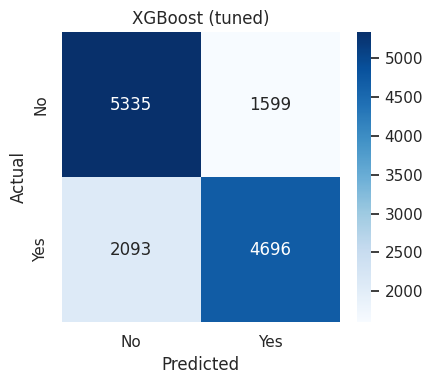

In [17]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(FINAL_NAME)
plt.tight_layout(); plt.show()

## ROC curve

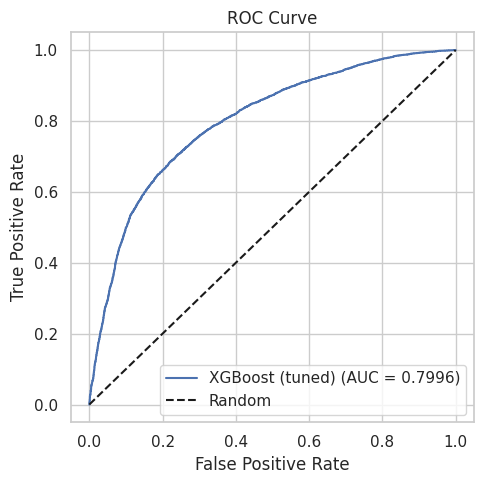

In [18]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"{FINAL_NAME} (AUC = {test_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve"); plt.legend()
plt.tight_layout(); plt.show()

## Error direction analysis

In [19]:
tn, fp, fn, tp = cm.ravel()
total = cm.sum()

print(f"True Negatives  (correct, no disease)      : {tn}  ({tn/total:.1%})")
print(f"True Positives  (correct, disease)         : {tp}  ({tp/total:.1%})")
print(f"False Positives (predicted disease, no)    : {fp}  ({fp/total:.1%})  -> unnecessary follow-up")
print(f"False Negatives (predicted no, has disease): {fn}  ({fn/total:.1%})  -> missed real risk case")

print(f"\nFN/FP ratio: {fn/fp if fp else float('nan'):.2f}")
print(f"Recall (sensitivity): {tp/(tp+fn):.4f}  -> share of real cardio cases caught")
print(f"Specificity         : {tn/(tn+fp):.4f}  -> share of healthy cases correctly cleared")
print("\nFalse negatives are the clinically costlier error here: a missed cardiovascular risk case")
print("carries more downside than an unnecessary follow-up test. If FN > FP, consider lowering the")
print("decision threshold below 0.5 to trade some specificity for recall.")

True Negatives  (correct, no disease)      : 5335  (38.9%)
True Positives  (correct, disease)         : 4696  (34.2%)
False Positives (predicted disease, no)    : 1599  (11.7%)  -> unnecessary follow-up
False Negatives (predicted no, has disease): 2093  (15.3%)  -> missed real risk case

FN/FP ratio: 1.31
Recall (sensitivity): 0.6917  -> share of real cardio cases caught
Specificity         : 0.7694  -> share of healthy cases correctly cleared

False negatives are the clinically costlier error here: a missed cardiovascular risk case
carries more downside than an unnecessary follow-up test. If FN > FP, consider lowering the
decision threshold below 0.5 to trade some specificity for recall.


## Threshold tuning

In [20]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)

best_idx = f1s[:-1].argmax()
best_thresh = thresholds[best_idx]

recall_target = 0.90
above = np.where(recalls[:-1] >= recall_target)[0]
recall_thresh = thresholds[above[-1]] if len(above) else 0.5

for label, t in [("Default (0.50)", 0.5), ("Best F1", best_thresh), (f"Recall >= {recall_target:.0%}", recall_thresh)]:
    pred_t = (y_proba >= t).astype(int)
    print(f"{label:<20} thresh={t:.3f}  Precision={precision_score(y_test,pred_t):.4f}  "
          f"Recall={recall_score(y_test,pred_t):.4f}  F1={f1_score(y_test,pred_t):.4f}")

print("\nDefault 0.5 is not guaranteed optimal. Given false negatives (missed risk cases) are the")
print("costlier error, the recall-targeted threshold is the more clinically defensible choice even")
print("if its F1 is slightly lower.")

Default (0.50)       thresh=0.500  Precision=0.7460  Recall=0.6917  F1=0.7178
Best F1              thresh=0.357  Precision=0.6643  Recall=0.8300  F1=0.7380
Recall >= 90%        thresh=0.278  Precision=0.6109  Recall=0.9001  F1=0.7278

Default 0.5 is not guaranteed optimal. Given false negatives (missed risk cases) are the
costlier error, the recall-targeted threshold is the more clinically defensible choice even
if its F1 is slightly lower.


## Feature importance

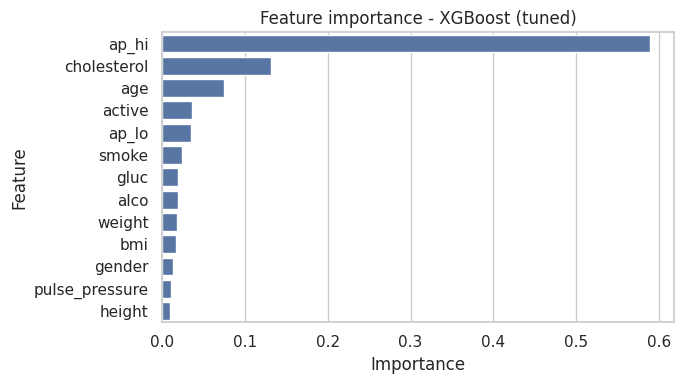

,Feature,Importance
4,ap_hi,0.5885
6,cholesterol,0.1315
0,age,0.0755
10,active,0.0366
5,ap_lo,0.0349
8,smoke,0.0245
7,gluc,0.0196
9,alco,0.0192
3,weight,0.0180
11,bmi,0.0175


In [21]:
est = final_model.named_steps["model"]
if hasattr(est, "feature_importances_"):
    imp = pd.DataFrame({"Feature": num_cols, "Importance": est.feature_importances_}) \
            .sort_values("Importance", ascending=False)
    plt.figure(figsize=(7, 4))
    sns.barplot(data=imp, x="Importance", y="Feature")
    plt.title(f"Feature importance - {FINAL_NAME}")
    plt.tight_layout(); plt.show()
    display(imp.round(4))
elif hasattr(est, "coef_"):
    coef = pd.DataFrame({"Feature": num_cols, "Coefficient": est.coef_[0]}) \
             .sort_values("Coefficient", key=abs, ascending=False)
    display(coef.round(4))

## SHAP

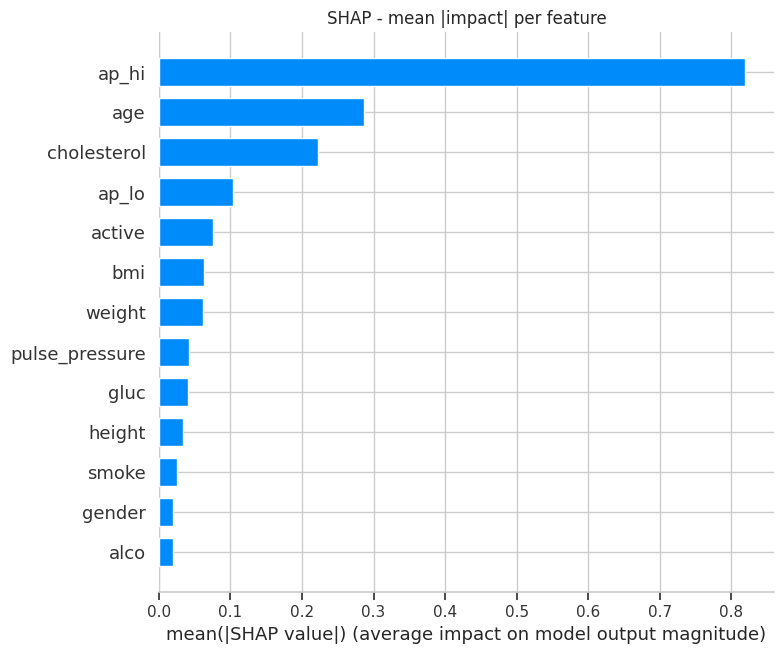

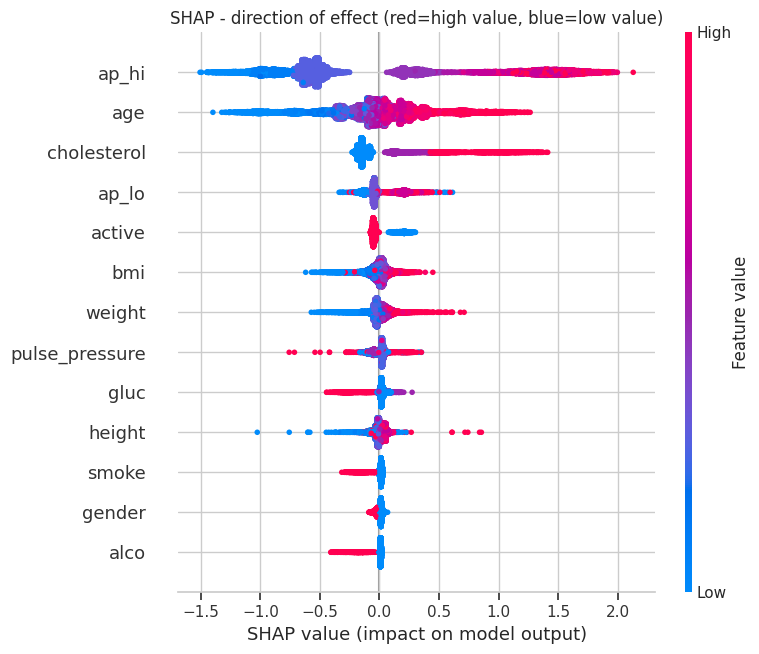

In [22]:
import shap
X_test_scaled = pd.DataFrame(final_model.named_steps["prep"].transform(X_test), columns=num_cols)

if hasattr(est, "feature_importances_"):
    explainer = shap.TreeExplainer(est)
    shap_values = explainer.shap_values(X_test_scaled)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]
else:
    bg = shap.sample(pd.DataFrame(final_model.named_steps["prep"].transform(X_train), columns=num_cols),
                     50, random_state=RANDOM_STATE)
    explainer = shap.KernelExplainer(est.predict_proba, bg)
    X_test_scaled = X_test_scaled.iloc[:200]
    shap_values = explainer.shap_values(X_test_scaled)[1]

shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", show=False)
plt.title("SHAP - mean |impact| per feature"); plt.tight_layout(); plt.show()

shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.title("SHAP - direction of effect (red=high value, blue=low value)")
plt.tight_layout(); plt.show()

## Duplicate-leakage sensitivity check

In [23]:
df_dedup = df.drop_duplicates().reset_index(drop=True)
print(f"Original: {len(df)}   De-duplicated: {len(df_dedup)}   Removed: {len(df)-len(df_dedup)}")

if len(df_dedup) < len(df):
    Xd, yd = df_dedup[num_cols], df_dedup[TARGET]
    Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, test_size=0.2, random_state=RANDOM_STATE, stratify=yd)
    from sklearn.base import clone
    dedup_model = clone(final_model)
    dedup_model.fit(Xd_tr, yd_tr)
    dedup_f1 = f1_score(yd_te, dedup_model.predict(Xd_te))
    print(f"Test F1 WITH duplicates   : {f1_score(y_test, y_pred):.4f}")
    print(f"Test F1 WITHOUT duplicates: {dedup_f1:.4f}")
    print(f"Difference: {f1_score(y_test, y_pred) - dedup_f1:+.4f}")
else:
    print("No duplicates present.")

Original: 68614   De-duplicated: 67940   Removed: 674
Test F1 WITH duplicates   : 0.7178
Test F1 WITHOUT duplicates: 0.7175
Difference: +0.0003


## Summary table

In [24]:
summary = cv_results.copy()
for name, search in tuned.items():
    summary.loc[summary["Model"] == name, "Model"] = f"{name} (before tuning)"
tuned_rows = pd.DataFrame([{
    "Model": f"{n} (tuned)", "CV F1 mean": s.best_score_, "CV F1 std": np.nan,
    "Accuracy": np.nan, "Precision": np.nan, "Recall": np.nan, "ROC-AUC": np.nan,
} for n, s in tuned.items()])
summary = pd.concat([summary, tuned_rows], ignore_index=True).sort_values("CV F1 mean", ascending=False)
display(summary.round(4))

print(f"\nFINAL MODEL: {FINAL_NAME}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}   Test F1: {f1_score(y_test, y_pred):.4f}   Test ROC-AUC: {test_auc:.4f}")

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,CV F1 mean,CV F1 std
5,XGBoost (tuned),NaN,NaN,NaN,NaN,NaN,0.7214,NaN
0,XGBoost (before tuning),0.7322,0.7515,0.6854,0.7169,0.7983,0.7169,0.0050
6,Logistic Regression (tuned),NaN,NaN,NaN,NaN,NaN,0.7095,NaN
1,Logistic Regression (before tuning),0.7288,0.7545,0.6695,0.7095,0.7916,0.7095,0.0034
2,Decision Tree,0.7232,0.7406,0.6780,0.7079,0.7788,0.7079,0.0056
3,KNN,0.7201,0.7321,0.6848,0.7077,0.7788,0.7077,0.0024
4,Random Forest,0.7123,0.7142,0.6976,0.7058,0.7728,0.7058,0.0042



FINAL MODEL: XGBoost (tuned)
Test Accuracy: 0.7310   Test F1: 0.7178   Test ROC-AUC: 0.7996


## Save final model

In [25]:
import joblib
joblib.dump(final_model, "cardio_final_model.pkl")
files.download("cardio_final_model.pkl")
print(f"Saved: {FINAL_NAME}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved: XGBoost (tuned)
